# Lab 6.01 - Regression analysis

In [1]:
# Package imports
import numpy as np                                  # "Scientific computing"
import scipy.stats as stats                         # Statistical tests

import pandas as pd                                 # Dataframe
import matplotlib.pyplot as plt                     # Basic visualisation
from statsmodels.graphics.mosaicplot import mosaic  # Mosaic plot
import seaborn as sns                               # Advanced dataviz
from sklearn.linear_model import LinearRegression

## Exercise 1: Relation between heart weight and body weight in Cats

### Part 1

Perform a linear regression analysis on the variables body weight (`Bwt`, dependent variable) and heart weight (`Hwt`, independent variabele).


1. Import the dataset `Cats.csv`.


In [2]:
cats = pd.read_csv('https://raw.githubusercontent.com/HoGentTIN/dsai-labs/main/data/Cats.csv')
# Show the first few records of the Data Frame
cats.head()

,ID,Sex,Hwt,Bwt
0,1,F,2.0,7.0
1,2,F,2.0,7.4
2,3,F,2.0,9.5
3,4,F,2.1,7.2
4,5,F,2.1,7.3


2. Draw a scatter plot of both variables.


<Axes: xlabel='Hwt', ylabel='Bwt'>

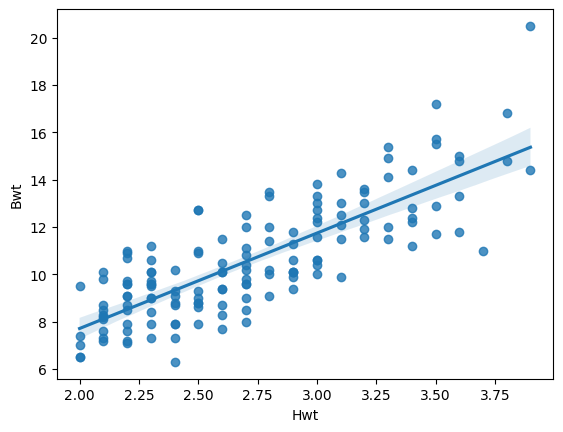

In [6]:
sns.regplot(cats, x='Hwt', y='Bwt')

3. Calculate and draw the regression line.


In [14]:
slope, y_intercept  = np.polyfit(cats['Hwt'], cats['Bwt'], deg=1)
y_intercept, slope

(np.float64(-0.3510783771969617), np.float64(4.031757486783179))

In [22]:
xmin = cats['Hwt'].min()
xmax = cats['Hwt'].max()

print(xmin, xmax)

2.0 3.9


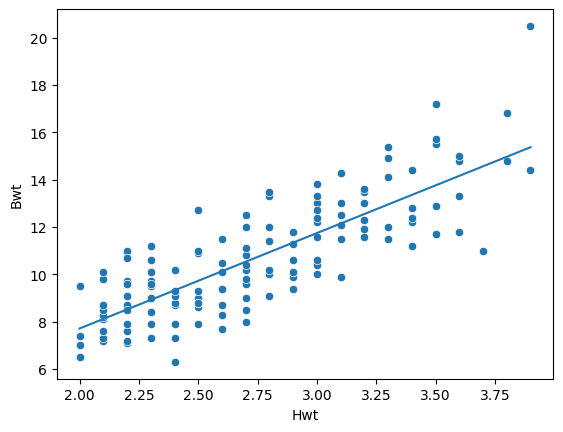

In [23]:
x_values = [xmin, xmax]
y_values = [slope * x_values[0] + y_intercept, slope * x_values[1] + y_intercept]

sns.lineplot(x=x_values, y=y_values);
sns.scatterplot(x=cats['Hwt'], y=cats['Bwt']);

4. Calculate the correlation coefficient and the coefficient of determination.

In [32]:
# [[cov(a,a), cov(a,b)],
#  [cov(b,a)  cov(b,b)]]

cor = np.corrcoef(x=cats['Hwt'], y=cats['Bwt'])[0][1]

print(f"R = {cor}, R**2 {cor**2}")

R = 0.804134787315513, R**2 0.6466327561709654


5. Interpret the results from the previous steps.

In [ ]:
# R > 0 -> stijgend verband
# R ~ 0.8 -> sterk verband
# R**2 ~ 0.8**2 = 0.64 = 64% van de variantie van de dep var wordt verklaard door de indep var

### Part 2

1. Perform a linear regression analysis on the variables body weight (`Bwt`) and heart weight (`Hwt`), but this time **subdivided by gender** (`Sex`). Use the same dataset (`Cats.csv`).


In [33]:
cats = pd.read_csv('https://raw.githubusercontent.com/HoGentTIN/dsai-labs/main/data/Cats.csv')
# Show the first few records of the Data Frame
cats.head()

,ID,Sex,Hwt,Bwt
0,1,F,2.0,7.0
1,2,F,2.0,7.4
2,3,F,2.0,9.5
3,4,F,2.1,7.2
4,5,F,2.1,7.3


In [41]:
katers = cats[cats['Sex']=='M']
kattinnen = cats[cats['Sex']=='F']

2. Draw a scatter plot of both variables for each gender.


<Axes: xlabel='Hwt', ylabel='Bwt'>

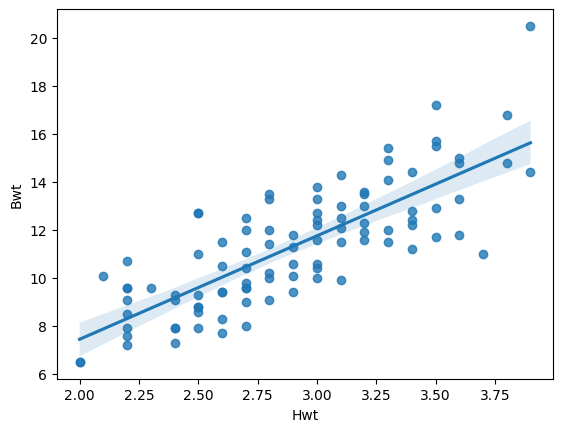

In [42]:
sns.regplot(katers, x='Hwt', y='Bwt')

<Axes: xlabel='Hwt', ylabel='Bwt'>

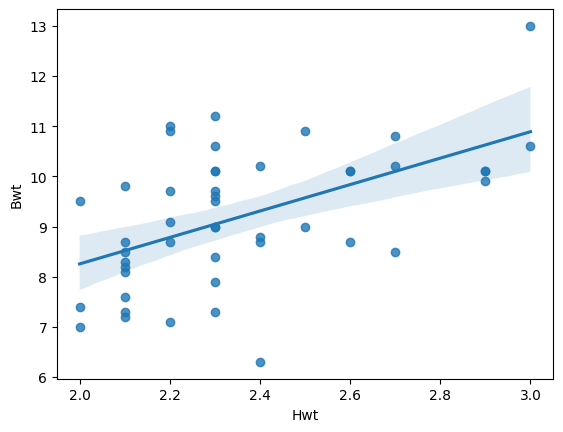

In [43]:
sns.regplot(kattinnen, x='Hwt', y='Bwt')

3. Calculate and draw the regression line.


In [44]:
slope, y_intercept  = np.polyfit(katers['Hwt'], katers['Bwt'], deg=1)
y_intercept, slope

(np.float64(-1.1768252533094905), np.float64(4.309818875119162))

In [47]:
slope, y_intercept  = np.polyfit(kattinnen['Hwt'], kattinnen['Bwt'], deg=1)
y_intercept, slope

(np.float64(2.981312384473199), np.float64(2.6364140480591503))

Regression line: ŷ = -1.1768252533094827 + 4.309818875119161 x


4. Calculate the correlation coefficient and the coefficient of determination.


In [48]:
cor = np.corrcoef(x=katers['Hwt'], y=katers['Bwt'])[0][1]

print(f"R = {cor}, R**2 {cor**2}")

R = 0.7930443171812304, R**2 0.628919289013444


In [50]:
cor = np.corrcoef(x=kattinnen['Hwt'], y=kattinnen['Bwt'])[0][1]

print(f"R = {cor}, R**2 {cor**2}")

R = 0.5320496665060397, R**2 0.28307684762918806


5. Interpret the results from the previous steps.

In [ ]:
# Minder sterk dan bij de katers
# R > 0 -> stijgend verband
# R ~ 0.53 -> gemiddeld verband
# R**2 ~ 0.53**2 = 0.28 = 28% van de variantie van de dep var wordt verklaard door de indep var

### Answers

| Selection |  $\beta_0$ | $\beta_1$ |       $R$ |     $R^2$ |
| :-------- | ---------: | --------: | --------: | --------: |
| All       | -0.3510784 | 4.0317575 | 0.8041348 | 0.6466328 |
| Male      | -1.1768253 | 4.3098189 | 0.7930443 | 0.6289193 |
| Female    |  2.9813124 |  2.636414 | 0.5320497 | 0.2830768 |
